<a href="https://colab.research.google.com/github/leon-pscl/CPE313/blob/main/Pascual_Hands_on_Activity_2_1_Convolutional_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 2.1 : Convolutional Neural Network

#### Objective(s):

This activity aims to introduce how to build a convolutional neural network

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to build and train convolutional neural network
* Evaluate the accuracy and loss of the model using convolutional neural network

#### Resources:
* Jupyter Notebook
* CIFAR-10 dataset

#### Procedures
Load the necessary libraries

In [4]:
from __future__ import print_function
import keras
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D

import matplotlib.pyplot as plt
%matplotlib inline

* Shuffle the data
* Split the data into train and test sets

In [6]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


Check the image size

In [7]:

x_train[444].shape

(32, 32, 3)

Visualize one of the images

[9]


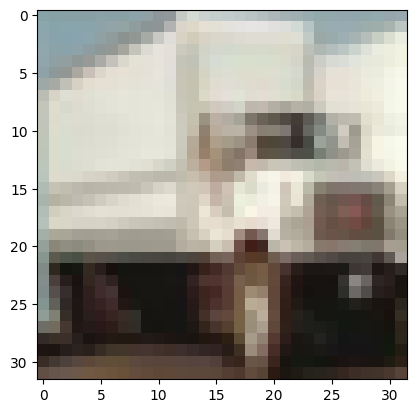

In [8]:
print(y_train[444])
plt.imshow(x_train[444]);

In [9]:
num_classes = 10

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Instead of classes described by an integer between 0-9 we have a vector with a 1 in the (Pythonic) 9th position

In [10]:
y_train[444]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

Convert to float and scale the datasets

In [11]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

Build a CNN using Keras Sequential

In [8]:

model_1 = Sequential()


## 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2), padding='same',
                 input_shape=x_train.shape[1:]))
model_1.add(Activation('relu'))

## Another 5x5 convolution with 2x2 stride and 32 filters
model_1.add(Conv2D(32, (5, 5), strides = (2,2)))
model_1.add(Activation('relu'))

## 2x2 max pooling reduces to 3 x 3 x 32
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.25))

## Flatten turns 3x3x32 into 288x1
model_1.add(Flatten())
model_1.add(Dense(512))
model_1.add(Activation('relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(num_classes))
model_1.add(Activation('softmax'))

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,162 (707.66 KB)

 Trainable params: 181,162 (707.66 KB)

 Non-trainable params: 0 (0.00 B)

* Use batch size of 32
* Initiate RMSprop optimizer
* Train the model using RMSprop

In [9]:
batch_size = 32

opt = keras.optimizers.RMSprop(learning_rate=0.0005)


model_1.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model_1.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=15,
              validation_data=(x_test, y_test))

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2800 - loss: 1.9437 - val_accuracy: 0.4653 - val_loss: 1.4794
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4561 - loss: 1.5103 - val_accuracy: 0.5144 - val_loss: 1.3551
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4968 - loss: 1.3967 - val_accuracy: 0.5573 - val_loss: 1.2434
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5299 - loss: 1.3180 - val_accuracy: 0.5441 - val_loss: 1.2995
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5527 - loss: 1.2632 - val_accuracy: 0.6012 - val_loss: 1.1330
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5698 - loss: 1.2130 - val_accuracy: 0.6104 - val_loss: 1.1137
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5834 - loss: 1.1775 - val_accuracy: 0.6117 - val_loss: 1.0802
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5932 - loss: 1.1583 

In [12]:
score_1 = model_1.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_1[0])
print('Test accuracy:', score_1[1])

Test loss: 1.1048458814620972
Test accuracy: 0.6129999756813049


#### Supplementary Activity

* Build a more complicated model with the following pattern:
Conv -> Conv -> MaxPool -> Conv -> Conv -> MaxPool -> (Flatten) -> Dense -> Final Classification

* Use strides of 1 for all convolutional layers.



In [10]:
supp_model = Sequential()


# Convolution 1
"""
32 filters/features detectors to learn
each filter is 5x5 pixels
the filter moves 1 pixel at a time horizontally(x) and vertically(y)
no padding, so output has same dimensions as the input
"""
supp_model.add(Conv2D(32, (5, 5), strides = (1,1), padding='same',
                 input_shape=x_train.shape[1:]))
# Convolution 2

supp_model.add(Conv2D(32, (5, 5), strides = (1,1), padding='same'))
## 2x2 max pooling reduces to 3 x 3 x 32
"""
Downsamples the feature maps by taking the max value in each 2x2 pixel window
cuts the dimensions in half
can help in reducing computation, control overfitting
"""
supp_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution 1
supp_model.add(Conv2D(32, (5, 5), strides = (1,1), padding='same'))
# Convolution 2
supp_model.add(Conv2D(32, (5, 5), strides = (1,1), padding='same'))

## 2x2 max pooling reduces to 3 x 3 x 32
supp_model.add(MaxPooling2D(pool_size=(2, 2)))

supp_model.add(Flatten()) #convert 3D feature maps into 1D vector to be fed into the network's layers
supp_model.add(Dense(num_classes))
supp_model.add(Activation('softmax'))


supp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        20,490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,818 (389.91 KB)

 Trainable params: 99,818 (389.91 KB)

 Non-trainable params: 0 (0.00 B)

* Write the number of parameters of your model  and compare it to the previous model

* Train it for 5 epochs. Commpare the training time, loss and accuracy numbers (on both the training and validation sets)?



In [11]:
batch_size = 32

opt = keras.optimizers.RMSprop(learning_rate=0.0005)


supp_model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

supp_model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.4007 - loss: 1.6939 - val_accuracy: 0.5545 - val_loss: 1.2856
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6019 - loss: 1.1504 - val_accuracy: 0.6342 - val_loss: 1.0779
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6502 - loss: 1.0261 - val_accuracy: 0.6509 - val_loss: 1.0249
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6790 - loss: 0.9455 - val_accuracy: 0.6327 - val_loss: 1.0503
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6983 - loss: 0.8820 - val_accuracy: 0.6173 - val_loss: 1.1630


In [13]:
score_supp_model = supp_model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_supp_model[0])
print('Test accuracy:', score_supp_model[1])

Test loss: 1.1048458814620972
Test accuracy: 0.6129999756813049


* Use different structures and run times, and see how accurate your model can be.

model_2

In [12]:
from keras.layers import BatchNormalization

model_2 = Sequential()

"""
3 convolutional blocks with progressively more filters
"""
# Input Convolution 1
model_2.add(Conv2D(32, (3, 3), strides = (1,1), padding='same',
                 input_shape=x_train.shape[1:]))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())

# 32 filters
model_2.add(Conv2D(32, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(32, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(32, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu')) #adds non-l
model_2.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# 64 filters
model_2.add(Conv2D(64, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(64, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(64, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(64, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_2.add(MaxPooling2D((2,2)))
model_2.add(Dropout(0.25))

# 128 filters
model_2.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())
model_2.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_2.add(Activation('relu'))
model_2.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_2.add(MaxPooling2D((2,2)))
model_2.add(Dropout(0.25))

model_2.add(Flatten())
model_2.add(Dense(256,))
model_2.add(Activation('relu'))
model_2.add(Dropout(0.5))
# Output
model_2.add(Dense(num_classes))
model_2.add(Activation('softmax'))


model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           25

 Total params: 1,205,226 (4.60 MB)

 Trainable params: 1,203,434 (4.59 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [14]:
batch_size = 32

opt = keras.optimizers.RMSprop(learning_rate=0.0005)


model_2.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model_2.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=5,
              validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.2807 - loss: 2.0929 - val_accuracy: 0.5288 - val_loss: 1.3489
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5561 - loss: 1.2854 - val_accuracy: 0.5804 - val_loss: 1.4529
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.6401 - loss: 1.0686 - val_accuracy: 0.6978 - val_loss: 0.9625
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6839 - loss: 0.9582 - val_accuracy: 0.6843 - val_loss: 1.0696
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7166 - loss: 0.8775 - val_accuracy: 0.7251 - val_loss: 0.8937


In [17]:
score_model_2 = model_2.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_model_2[0])
print('Test accuracy:', score_model_2[1])

Test loss: 0.8936702013015747
Test accuracy: 0.7250999808311462


model_3

In [20]:
from keras.layers import BatchNormalization

model_3 = Sequential()


# Input Convolution 1
model_3.add(Conv2D(64, (3, 3), strides = (1,1), padding='same',
                 input_shape=x_train.shape[1:]))
model_3.add(Activation('relu'))
model_3.add(BatchNormalization())

# instead of 32, use 128 filters
model_3.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_3.add(Activation('relu'))
model_3.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_3.add(MaxPooling2D((2,2)))
model_3.add(Dropout(0.25))

# instead of 128, use 256 filters
model_3.add(Conv2D(256, (3, 3), strides = (1,1), padding='same'))
model_3.add(Activation('relu'))
model_3.add(BatchNormalization())
model_3.add(Conv2D(256, (3, 3), strides = (1,1), padding='same'))
model_3.add(Activation('relu'))
model_3.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_3.add(MaxPooling2D((2,2)))
model_3.add(Dropout(0.25))

# instead of 256 filters, use 512 filters
model_3.add(Conv2D(512, (3, 3), strides = (1,1), padding='same'))
model_3.add(Activation('relu'))
model_3.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_3.add(MaxPooling2D((2,2)))
model_3.add(Dropout(0.25))

model_3.add(Flatten())
model_3.add(Dense(256,))
model_3.add(Activation('relu'))
model_3.add(Dropout(0.5))
# Output
model_3.add(Dense(num_classes))
model_3.add(Activation('softmax'))


model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,245,898 (16.20 MB)

 Trainable params: 4,243,466 (16.19 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [26]:
batch_size = 32

opt = keras.optimizers.RMSprop(learning_rate=0.0005)


model_3.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model_3.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=20,
              validation_data=(x_test, y_test))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.6642 - loss: 1.0619 - val_accuracy: 0.6727 - val_loss: 1.1480
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 21ms/step - accuracy: 0.6878 - loss: 1.0067 - val_accuracy: 0.7044 - val_loss: 0.8587
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7024 - loss: 0.9384 - val_accuracy: 0.7074 - val_loss: 1.3098
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7271 - loss: 0.8690 - val_accuracy: 0.7434 - val_loss: 0.8656
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7409 - loss: 0.8311 - val_accuracy: 0.7588 - val_loss: 0.9765
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7551 - loss: 0.7787 - val_accuracy: 0.7894 - val_loss: 0.7021
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7681 - loss: 0.7395 - val_accuracy: 0.7768 - val_loss: 0.8183
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7832 -

In [29]:
score_model_3 = model_3.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_model_3[0])
print('Test accuracy:', score_model_3[1])

Test loss: 0.7922180891036987
Test accuracy: 0.809499979019165


model_4

In [30]:
from keras.layers import BatchNormalization

model_4 = Sequential()


# Input Convolution 1
model_4.add(Conv2D(64, (3, 3), strides = (1,1), padding='same',
                 input_shape=x_train.shape[1:]))
model_4.add(Activation('relu'))
model_4.add(BatchNormalization())

# 32 filters
model_4.add(Conv2D(64, (3, 3), strides = (1,1), padding='same'))
model_4.add(Activation('relu'))
model_4.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_4.add(MaxPooling2D((2,2)))
model_4.add(Dropout(0.25))

# 128 filters
model_4.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_4.add(Activation('relu'))
model_4.add(BatchNormalization())
model_4.add(Conv2D(128, (3, 3), strides = (1,1), padding='same'))
model_4.add(Activation('relu'))
model_4.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_4.add(MaxPooling2D((2,2)))
model_4.add(Dropout(0.25))

#256 filters
model_4.add(Conv2D(256, (3, 3), strides = (1,1), padding='same'))
model_4.add(Activation('relu'))
model_4.add(BatchNormalization())

## 2x2 max pooling reduces to 3 x 3 x 32
model_4.add(MaxPooling2D((2,2)))
model_4.add(Dropout(0.25))

model_4.add(Flatten())
model_4.add(Dense(256,))
model_4.add(Activation('relu'))
model_4.add(Dropout(0.5))
# Output
model_4.add(Dense(num_classes))
model_4.add(Activation('softmax'))


model_4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,609,290 (6.14 MB)

 Trainable params: 1,608,010 (6.13 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [34]:
batch_size = 32

opt = keras.optimizers.Adam(learning_rate=0.0005)


model_5.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model_5.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=32,
              validation_data=(x_test, y_test))

Epoch 1/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.3052 - loss: 2.0927 - val_accuracy: 0.5014 - val_loss: 1.3848
Epoch 2/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5283 - loss: 1.3180 - val_accuracy: 0.6617 - val_loss: 0.9712
Epoch 3/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6194 - loss: 1.0832 - val_accuracy: 0.7186 - val_loss: 0.8154
Epoch 4/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6828 - loss: 0.9254 - val_accuracy: 0.7341 - val_loss: 0.8017
Epoch 5/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.7294 - loss: 0.7825 - val_accuracy: 0.7624 - val_loss: 0.6836
Epoch 6/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.7726 - loss: 0.6882 - val_accuracy: 0.7921 - val_loss: 0.6319
Epoch 7/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.7917 - loss: 0.6262 - val_accuracy: 0.7890 - val_loss: 0.6446
Epoch 8/32
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8178 -

In [36]:
score_model_4 = model_4.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_model_4[0])
print('Test accuracy:', score_model_4[1])

Test loss: 0.6130042672157288
Test accuracy: 0.8454999923706055


#### Conclusion

In this activity,I was able to demonstrate how to build and train a convolutional neural network. I thought that using more filters effectively and stacking more convolution blocks resulted in more parameters and consequently, more accurate results. However, when I widened the filters too far, the results got worse, which was unexpected.

In my efforts to resolve the problem, I learned that creating CNNs for specific tasks require just the right amount of filters and optimization techniques to get the desired accuracy. The number of learning epochs should also be noted as a factor in increasing the accuracy of the model. In my case, I was able to test the model with few learning epochs with wider filter dimenrsions, and models with more learning epochs but slightly narrower filter dimensions. More learning epochs still wins, as the dataset needs sufficient epochs for the neural network to converge to an accurate result.

